## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [17]:
df_user = df.groupby(['id_user','city','gender']).agg({'mon':'count',
                                                       'cnt_indiv':'sum',
                                                       'cnt_total':'sum',
                                                       'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonth'})

In [18]:
df_user.head()

,id_user,city,gender,nmonth,cnt_indiv,cnt_total,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,23,129,124800
2,1002,Москва,male,11,64,128,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600


In [19]:
df_user['share_indiv'] = round(df_user['cnt_indiv']/df_user['cnt_total'],2)
df_user['avg_pay_per_month'] = round(df_user['sum_total']/df_user['nmonth'],2)
df_user['cnt_train_per_month'] = round(df_user['cnt_indiv']/df_user['nmonth'],2)
df_user.head()

,id_user,city,gender,nmonth,cnt_indiv,cnt_total,sum_total,share_indiv,avg_pay_per_month,cnt_train_per_month
0,1000,СПб,female,9,33,33,58600,1.00,6511.11,3.67
1,1001,Москва,female,11,23,129,124800,0.18,11345.45,2.09
2,1002,Москва,male,11,64,128,166000,0.50,15090.91,5.82
3,1004,Екатеринбург,male,9,18,18,32000,1.00,3555.56,2.00
4,1005,СПб,female,2,7,7,12600,1.00,6300.00,3.50


In [20]:
df_user_indiv70 = df_user[df_user['share_indiv']>0.7].reset_index(drop = True)

In [21]:
df_user_indiv70.head()

,id_user,city,gender,nmonth,cnt_indiv,cnt_total,sum_total,share_indiv,avg_pay_per_month,cnt_train_per_month
0,1000,СПб,female,9,33,33,58600,1.0,6511.11,3.67
1,1004,Екатеринбург,male,9,18,18,32000,1.0,3555.56,2.00
2,1005,СПб,female,2,7,7,12600,1.0,6300.00,3.50
3,1007,Москва,female,4,5,5,9000,1.0,2250.00,1.25
4,1009,Москва,female,4,9,9,16200,1.0,4050.00,2.25


In [29]:
df_ind70 = df_user_indiv70.groupby(['city','gender']).agg(cnt_user = ('id_user','nunique'),\
                                                          avg_pay = ('avg_pay_per_month','mean'),\
                                                          cnt_train = ('cnt_train_per_month', 'mean')).reset_index()

In [30]:
df_ind70

,city,gender,cnt_user,avg_pay,cnt_train
0,Екатеринбург,female,12,5391.746667,3.009167
1,Екатеринбург,male,12,5832.395000,3.255000
2,Казань,female,8,6297.500000,3.412500
3,Казань,male,12,5229.378333,2.932500
4,Москва,female,118,5565.425593,3.132712
5,Москва,male,59,6915.316271,3.872712
6,СПб,female,32,6093.278750,3.399688
7,СПб,male,28,5024.889643,2.821429


**Наблюдения**
В целом практически одинаковое количество мужчин и женщин занимаются индивидуально, сильная разница только по г. Москва (женщин в 2 раза больше, чем мужчин). По среднему количеству тренировок и среднему чеку нет сильных различий.

### Задача 2. Топ-10 клиентов

In [51]:
df_top10 = df.groupby(['id_user', 'city', 'gender']).agg(cnt_all = ('cnt_total','sum')).\
                                                        sort_values('cnt_all', ascending = False).reset_index().head(10)
df_top10

,id_user,city,gender,cnt_all
0,1381,Москва,female,159
1,1013,Москва,male,151
2,1657,СПб,male,144
3,1506,Москва,female,138
4,1929,Москва,male,130
5,1001,Москва,female,129
6,1570,Екатеринбург,male,129
7,1002,Москва,male,128
8,1582,Екатеринбург,male,127
9,1194,СПб,female,127


In [49]:
top10_lst = df_top10['id_user'].tolist()
top10_lst

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [58]:
top_user = df[df['id_user'].isin(top10_lst)]
top_10 = top_user.groupby(['city','gender']).agg(cnt_user = ('id_user', 'nunique')).reset_index()
top_10

,city,gender,cnt_user
0,Екатеринбург,male,2
1,Москва,female,3
2,Москва,male,3
3,СПб,female,1
4,СПб,male,1


**Наблюдения** Наибольшее число активных пользователей в г. Москва. Количество одинаковое для каждого пола, т.е. активность пользователей не зависит от гендерного признака

### Задача 3. Динамика клиентской базы

In [64]:
df['mon'] = pd.to_datetime(df['mon'], format = '%Y-%m')
df['min_mon'] = pd.to_datetime(df['min_mon'], format = '%Y-%m')
df['max_mon'] = pd.to_datetime(df['max_mon'], format = '%Y-%m')

In [75]:
active_clients = df.groupby('mon').agg(active_clients = ('id_user','nunique')).reset_index()

In [76]:
new_clients = df.groupby(['min_mon']).agg(new_clients = ('id_user','nunique')).reset_index().\
                                            rename(columns = {'min_mon':'mon'})

In [80]:
gone_clients = df.groupby(['max_mon']).agg(gone_clients= ('id_user','nunique')).reset_index().\
                                            rename(columns = {'max_mon':'mon'})

In [83]:
merged_df = new_clients.merge(gone_clients, on='mon').merge(active_clients, on='mon')
merged_df

,mon,new_clients,gone_clients,active_clients
0,2023-01-01,337,15,337
1,2023-02-01,88,22,350
2,2023-03-01,83,37,355
3,2023-04-01,62,21,345
4,2023-05-01,57,21,360
5,2023-06-01,51,13,383
6,2023-07-01,48,33,412
7,2023-08-01,35,33,423
8,2023-09-01,28,55,429
9,2023-10-01,27,101,441


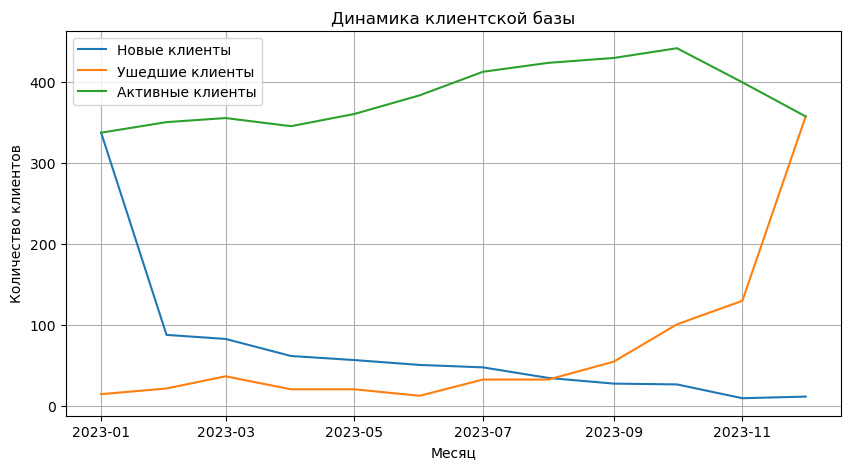

In [87]:
plt.figure(figsize=(10, 5)) 
plt.plot(merged_df['mon'], merged_df['new_clients'], label = 'Новые клиенты')
plt.plot(merged_df['mon'], merged_df['gone_clients'], label = 'Ушедшие клиенты')
plt.plot(merged_df['mon'], merged_df['active_clients'], label = 'Активные клиенты')
plt.xlabel('Месяц') # подписываем ось х
plt.ylabel('Количество клиентов') # подписываем ось y
plt.title('Динамика клиентской базы') #подписываем график
plt.grid(True) # добавляем сетку
plt.legend()
plt.show() # выводим график на экран